In [1]:
# 导入必要的库
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from mlxtend.classifier import StackingClassifier
from mlxtend.plotting import plot_decision_regions
import matplotlib.gridspec as gridspec
import itertools

# 加载 iris 数据集
iris = datasets.load_iris()
X = iris.data
y = iris.target

# 将数据集划分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 定义基学习器和融合模型
clf1 = KNeighborsClassifier(n_neighbors=3)
clf2 = RandomForestClassifier(n_estimators=100, random_state=42)
clf3 = GaussianNB()
lr = LogisticRegression()

# 创建 Stacking 分类器
sclf = StackingClassifier(classifiers=[clf1, clf2, clf3], meta_classifier=lr)

# 定义分类器列表，包括基学习器和融合模型
classifiers = [
    ('KNN', clf1),
    ('Random Forest', clf2),
    ('Naive Bayes', clf3),
    ('Stacking Classifier', sclf)
]

# 训练和评估每个分类器
for name, clf in classifiers:
    # 训练模型：基学习器在训练集上拟合，Stacking内部会进行交叉验证生成元特征
    clf.fit(X_train, y_train)
    
    # 预测测试集
    y_pred = clf.predict(X_test)
    
    # 计算准确率
    accuracy = accuracy_score(y_test, y_pred)
    
    # 输出评估结果
    print(f'{name}:')
    print(f'Accuracy: {accuracy:.2f}')  # 准确率反映整体预测正确率
    print('Confusion Matrix:')  # 混淆矩阵显示各类别的分类情况
    print(confusion_matrix(y_test, y_pred))
    print('Classification Report:')  # 包含精确率、召回率、F1值等指标
    print(classification_report(y_test, y_pred))
    
    # 使用 cross_val_score 进行交叉验证
    cv_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
    print(f'Cross-validation scores: {cv_scores}')  # 每个折的准确率
    print(f'Mean cross-validation accuracy: {np.mean(cv_scores):.2f} (±{np.std(cv_scores):.2f})')  # 平均准确率和标准差
    
    print('-' * 50)  # 分隔线

KNN:
Accuracy: 1.00
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Cross-validation scores: [0.95833333 1.         0.875      1.         0.95833333]
Mean cross-validation accuracy: 0.96 (±0.05)
--------------------------------------------------
Random Forest:
Accuracy: 1.00
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy     

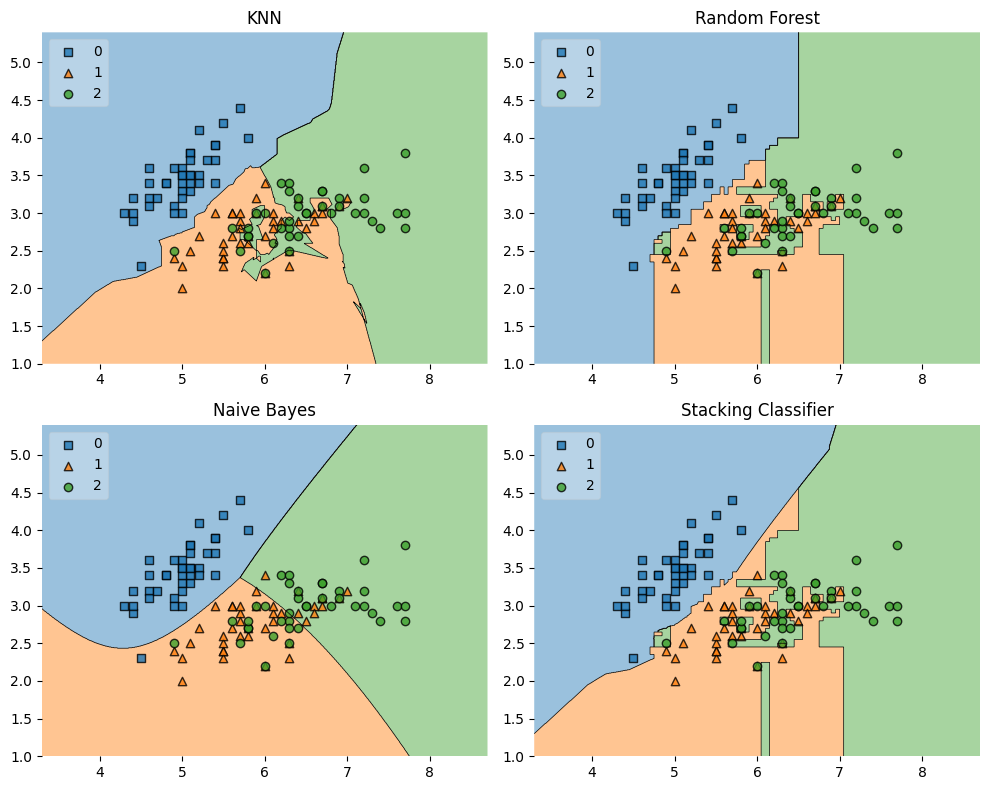

In [2]:
# 可视化决策边界（仅使用前两个特征以便在二维空间展示）
gs = gridspec.GridSpec(2, 2)  # 创建2x2的子图布局
fig = plt.figure(figsize=(10, 8))  # 设置画布大小

# 遍历分类器及其名称、网格位置
for clf, lab, grd in zip([clf1, clf2, clf3, sclf], 
                         ['KNN', 'Random Forest', 'Naive Bayes', 'Stacking Classifier'],
                         itertools.product([0, 1], repeat=2)):
    # 使用前两个特征重新训练模型（简化可视化，但可能影响模型实际表现）
    clf.fit(X_train[:, :2], y_train)
    ax = plt.subplot(gs[grd[0], grd[1]])  # 定位到指定子图
    # 绘制决策区域和数据点
    plot_decision_regions(X=X_train[:, :2], y=y_train, clf=clf, legend=2)
    plt.title(lab)  # 设置子图标题

plt.tight_layout()  # 自动调整子图间距
plt.show()